# Refraction and cave raypath sketches

This notebook draws simplified, pedagogical raypath diagrams for a 3-layer model with a 20 m × 20 m cave. It uses the geometry and velocities requested here:

- Layer 1: Vp = 1600 m/s, 0–10 m depth
- Layer 2: Vp = 3600 m/s, 10–35 m depth
- Layer 3: Vp = 4750 m/s, 35–80 m depth
- Cave: centered at x = 0 m, depth = 22.5 m, 20 m × 20 m

The raypaths are schematic rather than a full PyGIMLi/SPECFEM calculation. They are designed to illustrate (1) Snell's law bending across interfaces and (2) Fermat's principle / least-time behavior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# -----------------------------------------------------------------------------
# Geometry and layer properties
# -----------------------------------------------------------------------------

vp_layers = [1600.0, 3600.0, 4750.0]   # m/s
layer_names = [
    "Layer 1: unsaturated limestone",
    "Layer 2: saturated limestone",
    "Layer 3: low-porosity saturated limestone",
]
layer_colors = ["#fff4d6", "#dff0d8", "#d9ecff"]
z_nodes = [0.0, 10.0, 35.0, 80.0]

# Cave geometry: 20 m × 20 m, centered at x=0 and z=22.5 m.
cave_vp = 1500.0
cave_width_m = 20.0
cave_height_m = 20.0
cave_x1, cave_x2 = -10.0, 10.0
cave_z1, cave_z2 = 12.5, 32.5

# Full acquisition limits.
shot_min_x, shot_max_x = -150.0, 150.0
receiver_min_x, receiver_max_x = -140.0, 140.0

# Example endpoints used for the explanatory rays.
# The red head wave and the blue cave-transmitted ray terminate at the SAME geophone.
src_x = -150.0
rec_x = 140.0

# Output folder, if desired.
outdir = Path("raypath_figures")
outdir.mkdir(exist_ok=True)

print("Layer velocities:", vp_layers)
print("Cave Vp:", cave_vp)
print("Example shot, receiver:", src_x, rec_x)

Layer velocities: [1600.0, 3600.0, 4750.0]
Cave Vp: 1500.0
Example shot, receiver: -150.0 140.0


In [2]:
# -----------------------------------------------------------------------------
# Plotting and ray helper functions
# -----------------------------------------------------------------------------

def draw_velocity_profile(ax):
    """Draw the 1-D Vp model as a blocky step profile."""
    v_plot = [vp_layers[0], vp_layers[0], vp_layers[1], vp_layers[1], vp_layers[2], vp_layers[2]]
    z_plot = [z_nodes[0], z_nodes[1], z_nodes[1], z_nodes[2], z_nodes[2], z_nodes[3]]

    ax.plot(v_plot, z_plot, color="black", linewidth=2.5)
    ax.set_xlim(0, 5500)
    ax.set_ylim(z_nodes[-1], 0)
    ax.set_xlabel("P-wave speed [m/s]")
    ax.set_ylabel("Depth [m]")
    ax.set_title("Velocity model")
    ax.grid(True, linestyle=":", alpha=0.5)

    for i, vp in enumerate(vp_layers):
        z_mid = 0.5 * (z_nodes[i] + z_nodes[i + 1])
        ax.text(
            vp + 120,
            z_mid,
            f"{layer_names[i]}\nVp = {vp:.0f} m/s",
            va="center",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="0.6"),
        )


def draw_model_background(ax, with_cave=True):
    """Draw the layered 2-D model and optional cave."""
    x_min, x_max = -160.0, 160.0

    for i in range(3):
        ax.add_patch(
            patches.Rectangle(
                (x_min, z_nodes[i]),
                x_max - x_min,
                z_nodes[i + 1] - z_nodes[i],
                facecolor=layer_colors[i],
                edgecolor="none",
                zorder=0,
            )
        )
        z_mid = 0.5 * (z_nodes[i] + z_nodes[i + 1])
        ax.text(
            x_min + 5,
            z_mid,
            f"{layer_names[i]}\nVp = {vp_layers[i]:.0f} m/s",
            va="center",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.65, edgecolor="none"),
        )

    # Interfaces.
    for z in z_nodes:
        ax.axhline(z, color="black", linestyle="--" if z not in (0, z_nodes[-1]) else "-", linewidth=1.0, alpha=0.8)

    if with_cave:
        cave = patches.Rectangle(
            (cave_x1, cave_z1),
            cave_width_m,
            cave_height_m,
            facecolor="#f7fbff",
            edgecolor="black",
            linewidth=2,
            hatch="//",
            zorder=5,
        )
        ax.add_patch(cave)
        ax.text(
            0,
            22.5,
            f"Cave\n20 m × 20 m\nVp = {cave_vp:.0f} m/s",
            ha="center",
            va="center",
            fontsize=10,
            zorder=6,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

    # Shot and geophone ranges.
    ax.plot([shot_min_x, shot_max_x], [-1.5, -1.5], color="red", linewidth=2, clip_on=False)
    ax.text(0, -3.6, "shots: x = −150 to +150 m", color="red", ha="center", va="bottom", fontsize=10)
    ax.plot([receiver_min_x, receiver_max_x], [-3.0, -3.0], color="blue", linewidth=2, clip_on=False)
    ax.text(0, -5.1, "geophones: x = −140 to +140 m", color="blue", ha="center", va="bottom", fontsize=10)

    # Example shot and receiver.
    ax.scatter([src_x], [0], marker="*", s=180, color="red", edgecolor="black", zorder=10, label="example shot")
    ax.scatter([rec_x], [0], marker="v", s=100, color="blue", edgecolor="black", zorder=10, label="example geophone")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(z_nodes[-1], -6)
    ax.invert_yaxis()
    ax.set_xlabel("x [m]")
    ax.set_ylabel("Depth [m]")
    ax.grid(True, alpha=0.18)


def plot_ray(ax, points, color="black", label=None, linewidth=2.5, linestyle="-", marker=None, zorder=20):
    """Plot a piecewise-straight ray with small arrows showing propagation direction."""
    pts = np.asarray(points, dtype=float)
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=linewidth, linestyle=linestyle, marker=marker, label=label, zorder=zorder)

    # Add arrows at the middle of each segment.
    for p0, p1 in zip(pts[:-1], pts[1:]):
        mid = 0.55 * p0 + 0.45 * p1
        d = p1 - p0
        norm = np.hypot(d[0], d[1])
        if norm == 0:
            continue
        d = d / norm
        ax.annotate(
            "",
            xy=mid + 4.0 * d,
            xytext=mid - 4.0 * d,
            arrowprops=dict(arrowstyle="-|>", color=color, lw=linewidth * 0.7),
            zorder=zorder + 1,
        )


def head_wave_along_bottom_of_layer1(src, rec):
    """Critical refraction/head wave along z=10 m, the bottom of layer 1."""
    v1, v2 = vp_layers[0], vp_layers[1]
    z_int = z_nodes[1]
    theta_c = np.arcsin(v1 / v2)  # angle from vertical normal in layer 1
    dx = z_int * np.tan(theta_c)
    return np.array([[src, 0.0], [src + dx, z_int], [rec - dx, z_int], [rec, 0.0]])


def cave_transmitted_ray_same_endpoints(src, rec):
    """A constrained transmitted ray that passes through the cave interior.

    This is not claimed to be the first-arrival ray. It is a constructed Snell-law
    teaching ray: it is piecewise straight in homogeneous regions, nearly vertical
    in the slow upper layer, and flatter through the lower-velocity cave.
    """
    v1, v2 = vp_layers[0], vp_layers[1]
    z_int = z_nodes[1]

    # Use critical-angle distance in the upper layer so the top-layer segments are steep.
    theta_c = np.arcsin(v1 / v2)
    dx_top = z_int * np.tan(theta_c)

    return np.array([
        [src, 0.0],
        [src + dx_top, z_int],
        [cave_x1, 22.5],
        [cave_x2, 22.5],
        [rec - dx_top, z_int],
        [rec, 0.0],
    ])


def direct_upper_layer_ray(src, rec):
    """A very simple direct near-surface path, for comparison only."""
    return np.array([[src, 0.0], [rec, 0.0]])


def travel_time(points, velocities):
    """Travel time for a piecewise path, given one velocity per segment."""
    pts = np.asarray(points, dtype=float)
    velocities = np.asarray(velocities, dtype=float)
    lengths = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    return float(np.sum(lengths / velocities))


def path_length(points):
    pts = np.asarray(points, dtype=float)
    return float(np.sum(np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))))

## Snell's-law teaching example

The red ray is a head wave that travels along the bottom of Layer 1 (the 1600–3600 m/s interface) and arrives at the same geophone as the cave-transmitted ray. The blue ray is a constrained transmitted ray through the cave interior. It is shown to illustrate Snell's-law bending and is not necessarily the first arrival.

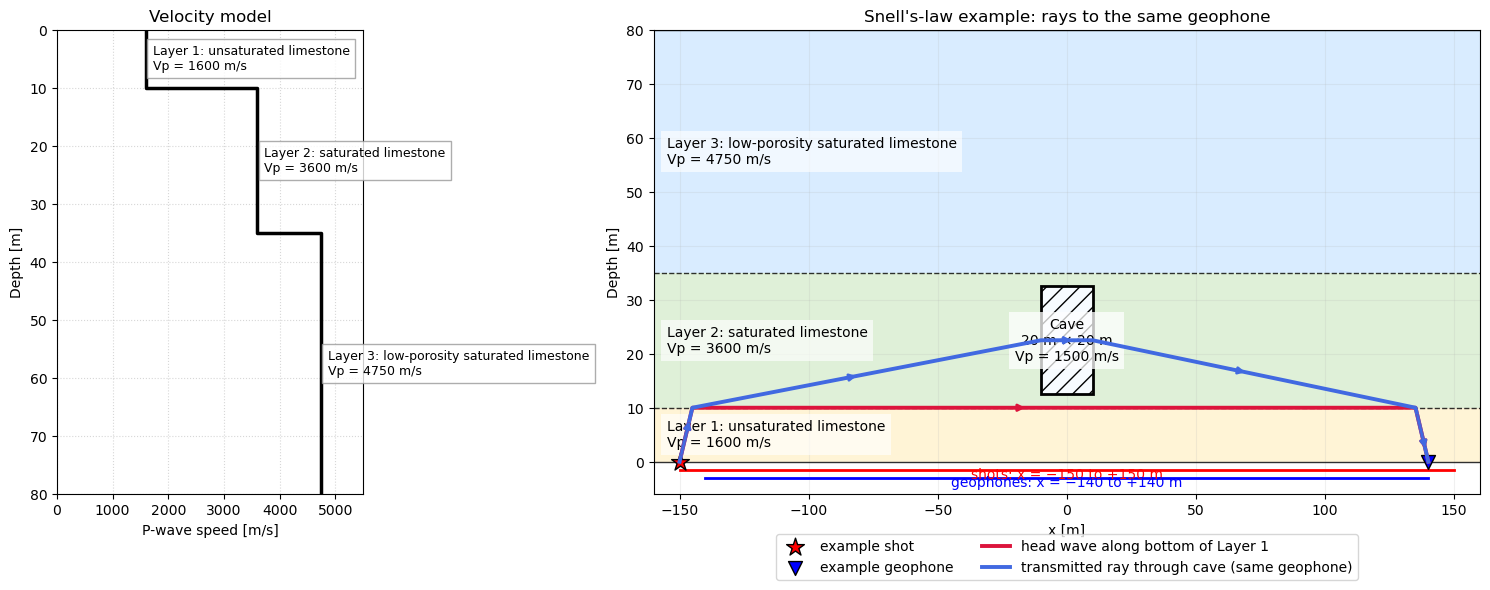

Head-wave travel time: 91.75 ms
Cave-transmitted travel time: 99.86 ms
Cave path is slower by: 8.11 ms


In [3]:
# -----------------------------------------------------------------------------
# Snell's-law teaching example: head wave and cave-transmitted ray to same geophone
# -----------------------------------------------------------------------------

head_ray = head_wave_along_bottom_of_layer1(src_x, rec_x)
cave_ray = cave_transmitted_ray_same_endpoints(src_x, rec_x)

fig, (ax_v, ax) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.0, 2.7]})

draw_velocity_profile(ax_v)
draw_model_background(ax, with_cave=True)

plot_ray(
    ax,
    head_ray,
    color="crimson",
    label="head wave along bottom of Layer 1",
    linewidth=2.8,
)
plot_ray(
    ax,
    cave_ray,
    color="royalblue",
    label="transmitted ray through cave (same geophone)",
    linewidth=2.8,
)

ax.set_title("Snell's-law example: rays to the same geophone")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.20), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

# Travel-time annotations.
head_t = travel_time(head_ray, [vp_layers[0], vp_layers[1], vp_layers[0]])
cave_t = travel_time(cave_ray, [vp_layers[0], vp_layers[1], cave_vp, vp_layers[1], vp_layers[0]])
print(f"Head-wave travel time: {1000*head_t:.2f} ms")
print(f"Cave-transmitted travel time: {1000*cave_t:.2f} ms")
print(f"Cave path is slower by: {1000*(cave_t-head_t):.2f} ms")

## Reference model without cave

For the no-cave reference model, the cave-transmitted ray is removed. This panel just shows the 3-layer velocity structure and the head wave along the bottom of Layer 1.

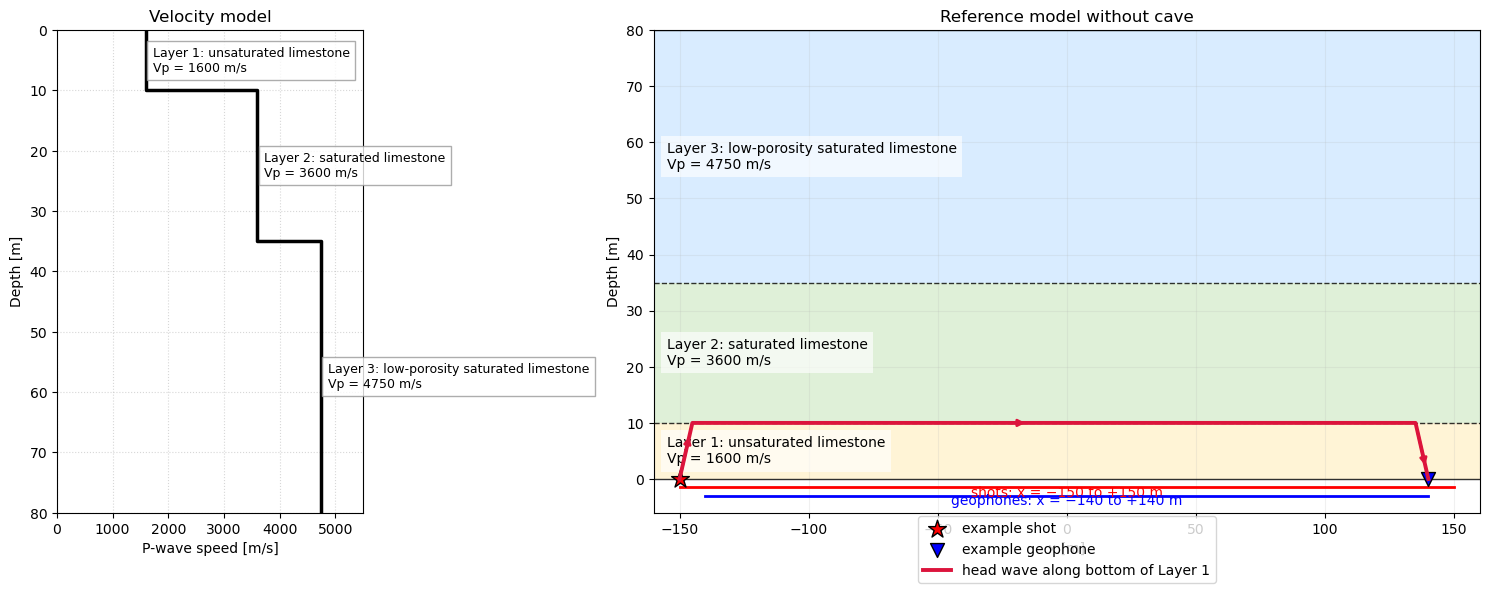

In [4]:
# -----------------------------------------------------------------------------
# Reference model without cave: remove the cave-transmitted ray entirely
# -----------------------------------------------------------------------------

fig, (ax_v, ax) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.0, 2.7]})

draw_velocity_profile(ax_v)
draw_model_background(ax, with_cave=False)
plot_ray(
    ax,
    head_ray,
    color="crimson",
    label="head wave along bottom of Layer 1",
    linewidth=2.8,
)

ax.set_title("Reference model without cave")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=1, frameon=True)
plt.tight_layout()
plt.show()

## Fermat's-principle example

Fermat's principle states that the first-arriving ray follows the path of least travel time, not necessarily the shortest geometric distance. Here the cave-transmitted path is longer in time because it spends part of the path in the slow cave. The head wave can arrive earlier because it travels most of the distance in faster limestone.

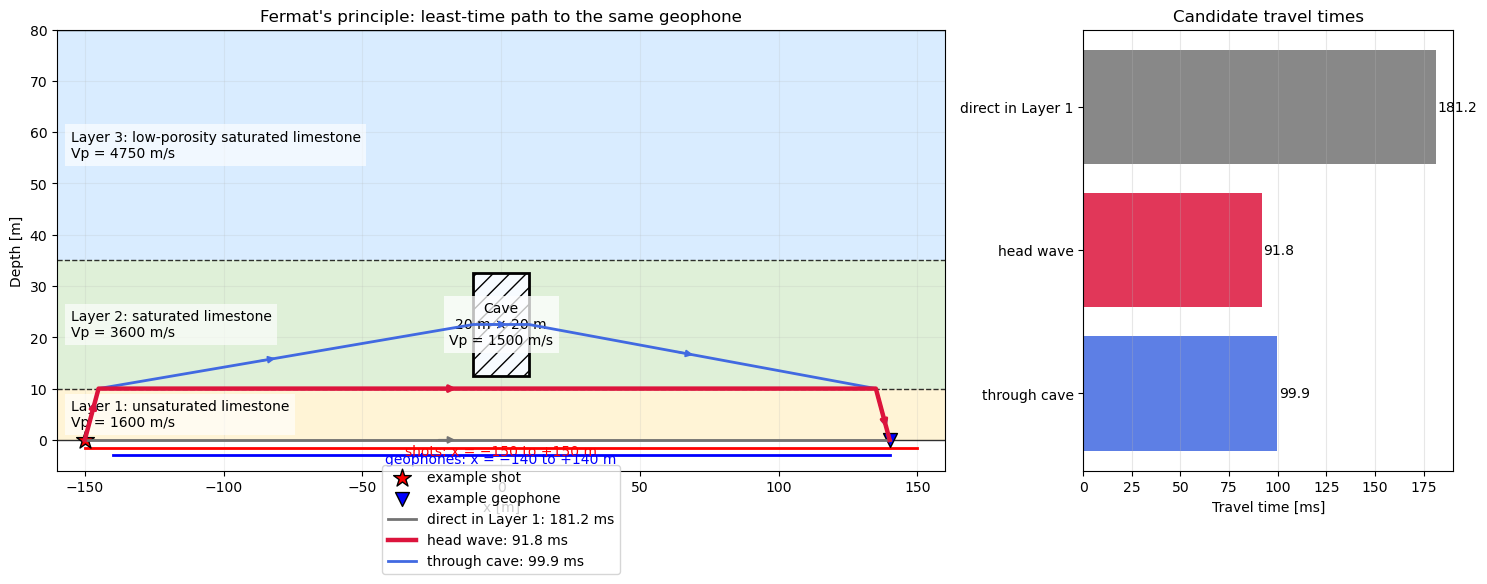

Fastest candidate path: head wave
direct in Layer 1   :   181.25 ms, length = 290.0 m
head wave           :    91.75 ms, length = 302.4 m
through cave        :    99.86 ms, length = 303.6 m


In [5]:
# -----------------------------------------------------------------------------
# Fermat principle: compare candidate paths to the same receiver
# -----------------------------------------------------------------------------

# Candidate paths to the same receiver.
# 1) Direct near-surface path: not a realistic refracted first arrival at long offsets,
#    but useful as a time comparison through slow Layer 1.
# 2) Head wave along bottom of Layer 1.
# 3) Cave-transmitted path.

direct_ray = direct_upper_layer_ray(src_x, rec_x)

candidate_paths = {
    "direct in Layer 1": (direct_ray, [vp_layers[0]], "0.45"),
    "head wave": (head_ray, [vp_layers[0], vp_layers[1], vp_layers[0]], "crimson"),
    "through cave": (cave_ray, [vp_layers[0], vp_layers[1], cave_vp, vp_layers[1], vp_layers[0]], "royalblue"),
}

times = {name: travel_time(path, vels) for name, (path, vels, _) in candidate_paths.items()}
fastest = min(times, key=times.get)

fig, (ax, ax_bar) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2.4, 1.0]})

draw_model_background(ax, with_cave=True)

for name, (path, vels, color) in candidate_paths.items():
    lw = 3.2 if name == fastest else 2.0
    alpha = 1.0 if name == fastest else 0.65
    plot_ray(ax, path, color=color, label=f"{name}: {1000*times[name]:.1f} ms", linewidth=lw, zorder=25 if name == fastest else 20)

ax.set_title("Fermat's principle: least-time path to the same geophone")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=1, frameon=True)

names = list(times.keys())
vals = [1000 * times[n] for n in names]
colors = [candidate_paths[n][2] for n in names]
ax_bar.barh(names, vals, color=colors, alpha=0.85)
ax_bar.invert_yaxis()
ax_bar.set_xlabel("Travel time [ms]")
ax_bar.set_title("Candidate travel times")
for i, v in enumerate(vals):
    ax_bar.text(v + 1, i, f"{v:.1f}", va="center")
ax_bar.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Fastest candidate path:", fastest)
for name, t in times.items():
    print(f"{name:20s}: {1000*t:8.2f} ms, length = {path_length(candidate_paths[name][0]):.1f} m")